# Linear Regression 2 - 아프리카 질병 감염률 예측

## 적용된 개선사항:
1. Target 로그 변환: log(infection_rate + 1)
2. Livestock 로그 변환: log(x + 1)
3. Buffa 제거 (모두 0이므로)
4. 온도 변수: avg_temperature만 사용 (다중공선성 제거)

## 1. 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 시각화 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 재현성을 위한 seed 설정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. 데이터 로드

In [2]:
# 데이터 로드
df = pd.read_csv('../data/processed/cleaned_disease_dataset_2015landuse.csv')

print(f"Total samples: {len(df):,}")
df.head()

Total samples: 473


,year,country,admin,infection_rate,max_temperature,min_temperature,avg_temperature,Buffa,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine,rate_landuse,missing_ratio
0,2010,Burkina Faso,Boucle Du Mouhoun,0.585652,307.42114,297.76172,302.50760,0.0,25.000049,164.065700,0.0,34.153420,0.693863,21.774243,9.682960,0.076206,0.0
1,2010,Burkina Faso,Cascades,0.979432,304.47192,297.88160,300.27893,0.0,38.008688,96.864817,0.0,12.506484,0.008877,12.373391,3.865450,0.074387,0.0
2,2010,Burkina Faso,Centre,1.955671,307.73170,299.50660,302.80447,0.0,17.566445,303.908919,0.0,58.134766,0.019041,40.947445,6.821150,0.407856,0.0
3,2010,Burkina Faso,Centre-est,1.037736,307.41138,298.78003,302.61942,0.0,29.597071,203.094681,0.0,69.010943,0.027864,45.871831,18.292361,0.143950,0.0
4,2010,Burkina Faso,Centre-nord,0.379147,308.31274,297.82104,303.14368,0.0,28.843678,138.295650,0.0,65.134086,0.079677,48.346972,4.834737,0.120649,0.0


## 3. 데이터 준비 및 변환

In [3]:
print("=== 데이터 변환 시작 ===")

# 원본 컬럼 정의
key_cols = ['year', 'country', 'admin']
target_col = 'infection_rate'
livestock_cols = ['Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']  # Buffa 제거됨!

# 개선 1: Buffa 제거 (모두 0이므로)
print("\n1. Buffa 제거")
print(f"   Buffa 값 확인: 최소={df['Buffa'].min()}, 최대={df['Buffa'].max()}, 합계={df['Buffa'].sum()}")
print("   → Buffa는 모두 0이므로 제거합니다.")

#  개선 2: Livestock 로그 변환
print("\n2. Livestock 변수 로그 변환 (log1p)")
df_transformed = df.copy()
for col in livestock_cols:
    original_mean = df[col].mean()
    df_transformed[f'{col}_log'] = np.log1p(df[col])  # log(1 + x)
    transformed_mean = df_transformed[f'{col}_log'].mean()
    print(f"   {col}: 평균 {original_mean:.2f} → {col}_log: 평균 {transformed_mean:.2f}")

# 로그 변환된 livestock 컬럼명
livestock_log_cols = [f'{col}_log' for col in livestock_cols]

# 개선 3: 온도 변수 하나만 사용 (avg_temperature)
print("\n3. 온도 변수: avg_temperature만 사용")
print(f"   max_temperature 제거 (avg와 상관계수: 0.93)")
print(f"   min_temperature 제거 (avg와 상관계수: 0.89)")
print(f"   → avg_temperature만 사용하여 다중공선성 제거")

# 최종 Feature 컬럼
feature_cols = ['avg_temperature'] + livestock_log_cols + ['rate_landuse']

print(f"\n최종 Feature 컬럼 ({len(feature_cols)}개):")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i}. {col}")

# 개선 4: Target 로그 변환
print("\n4. Target 변수 로그 변환 (log1p)")
print(f"   원본 infection_rate: 평균={df[target_col].mean():.4f}, 중앙값={df[target_col].median():.4f}")
df_transformed['infection_rate_log'] = np.log1p(df[target_col])
print(f"   변환 infection_rate_log: 평균={df_transformed['infection_rate_log'].mean():.4f}, 중앙값={df_transformed['infection_rate_log'].median():.4f}")
print(f"   → 왜도 개선: {df[target_col].skew():.4f} → {df_transformed['infection_rate_log'].skew():.4f}")

print("\n=== 데이터 변환 완료 ===")

=== 데이터 변환 시작 ===

1. Buffa 제거
   Buffa 값 확인: 최소=0.0, 최대=0.0, 합계=0.0
   → Buffa는 모두 0이므로 제거합니다.

2. Livestock 변수 로그 변환 (log1p)
   Cattl: 평균 21.18 → Cattl_log: 평균 2.41
   Chick: 평균 203.42 → Chick_log: 평균 4.18
   Ducks: 평균 1.09 → Ducks_log: 평균 0.25
   Goats: 평균 25.22 → Goats_log: 평균 2.64
   Horse: 평균 0.93 → Horse_log: 평균 0.33
   Sheep: 평균 17.25 → Sheep_log: 평균 2.17
   Swine: 평균 4.85 → Swine_log: 평균 1.13

3. 온도 변수: avg_temperature만 사용
   max_temperature 제거 (avg와 상관계수: 0.93)
   min_temperature 제거 (avg와 상관계수: 0.89)
   → avg_temperature만 사용하여 다중공선성 제거

최종 Feature 컬럼 (9개):
   1. avg_temperature
   2. Cattl_log
   3. Chick_log
   4. Ducks_log
   5. Goats_log
   6. Horse_log
   7. Sheep_log
   8. Swine_log
   9. rate_landuse

4. Target 변수 로그 변환 (log1p)
   원본 infection_rate: 평균=5.4209, 중앙값=2.1459
   변환 infection_rate_log: 평균=1.4237, 중앙값=1.1461
   → 왜도 개선: 1.5401 → 0.5870

=== 데이터 변환 완료 ===


In [4]:
# X, y 분리 (변환된 데이터 사용)
X = df_transformed[feature_cols].copy()
y = df_transformed['infection_rate_log'].copy()  # 로그 변환된 target

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\n사용된 Features: {list(X.columns)}")

X shape: (473, 9)
y shape: (473,)

사용된 Features: ['avg_temperature', 'Cattl_log', 'Chick_log', 'Ducks_log', 'Goats_log', 'Horse_log', 'Sheep_log', 'Swine_log', 'rate_landuse']


## 4. Train/Test Split

In [5]:
# Random Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("=== Random Split ===")
print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain - y(log) 평균: {y_train.mean():.4f}, 표준편차: {y_train.std():.4f}")
print(f"Test - y(log) 평균: {y_test.mean():.4f}, 표준편차: {y_test.std():.4f}")

=== Random Split ===
Train set: 378 samples (79.9%)
Test set: 95 samples (20.1%)

Train - y(log) 평균: 1.4366, 표준편차: 0.9008
Test - y(log) 평균: 1.3726, 표준편차: 0.8881


## 5. Feature Scaling

In [6]:
# StandardScaler 적용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== Scaling 전후 비교 ===")
print("\n[Scaling 전]")
print(f"Train - 평균: {X_train.mean().mean():.4f}, 표준편차: {X_train.std().mean():.4f}")
print(f"Test - 평균: {X_test.mean().mean():.4f}, 표준편차: {X_test.std().mean():.4f}")

print("\n[Scaling 후]")
print(f"Train - 평균: {X_train_scaled.mean():.4f}, 표준편차: {X_train_scaled.std():.4f}")
print(f"Test - 평균: {X_test_scaled.mean():.4f}, 표준편차: {X_test_scaled.std():.4f}")

# DataFrame으로 변환 (feature 이름 유지)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

=== Scaling 전후 비교 ===

[Scaling 전]
Train - 평균: 34.5219, 표준편차: 1.3543
Test - 평균: 34.5386, 표준편차: 1.3396

[Scaling 후]
Train - 평균: -0.0000, 표준편차: 1.0000
Test - 평균: -0.0049, 표준편차: 1.1093


## 6. Linear Regression 모델 학습

In [7]:
# 모델 초기화 및 학습
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("=== Linear Regression 모델 학습 완료 ===")
print(f"Intercept (절편): {lr_model.intercept_:.4f}")
print(f"Number of features: {len(lr_model.coef_)}")

=== Linear Regression 모델 학습 완료 ===
Intercept (절편): 1.4366
Number of features: 9


## 7. 예측 및 역변환

Target을 로그 변환했으므로 예측값을 원래 스케일로 역변환합니다.

In [8]:
# Train/Test 예측 (로그 스케일)
y_train_pred_log = lr_model.predict(X_train_scaled)
y_test_pred_log = lr_model.predict(X_test_scaled)

# 역변환: log 스케일 → 원본 스케일
y_train_pred = np.expm1(y_train_pred_log)  # exp(x) - 1
y_test_pred = np.expm1(y_test_pred_log)

# 실제 값도 원본 스케일로 (비교를 위해)
y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)

print("=== 예측 완료 ===")
print(f"Train predictions (log scale): {y_train_pred_log.shape}")
print(f"Test predictions (log scale): {y_test_pred_log.shape}")
print(f"\n역변환 완료 (원본 스케일)")
print(f"Train predictions (original scale): {y_train_pred.shape}")
print(f"Test predictions (original scale): {y_test_pred.shape}")

=== 예측 완료 ===
Train predictions (log scale): (378,)
Test predictions (log scale): (95,)

역변환 완료 (원본 스케일)
Train predictions (original scale): (378,)
Test predictions (original scale): (95,)


## 8. 모델 평가

원본 스케일에서 평가합니다.

In [9]:
# 평가 지표 계산
def evaluate_model(y_true, y_pred, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE: 0인 값 제외
    mask = y_true > 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.inf
    
    print(f"\n=== {dataset_name} Set Performance (원본 스케일) ===")
    print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
    print(f"MAE (Mean Absolute Error): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

train_metrics = evaluate_model(y_train_actual, y_train_pred, "Train")
test_metrics = evaluate_model(y_test_actual, y_test_pred, "Test")


=== Train Set Performance (원본 스케일) ===
RMSE (Root Mean Squared Error): 5.1506
MAE (Mean Absolute Error): 3.2286
R² Score: 0.4085
MAPE (Mean Absolute Percentage Error): 124.96%

=== Test Set Performance (원본 스케일) ===
RMSE (Root Mean Squared Error): 4.8878
MAE (Mean Absolute Error): 3.2662
R² Score: 0.3670
MAPE (Mean Absolute Percentage Error): 156.91%


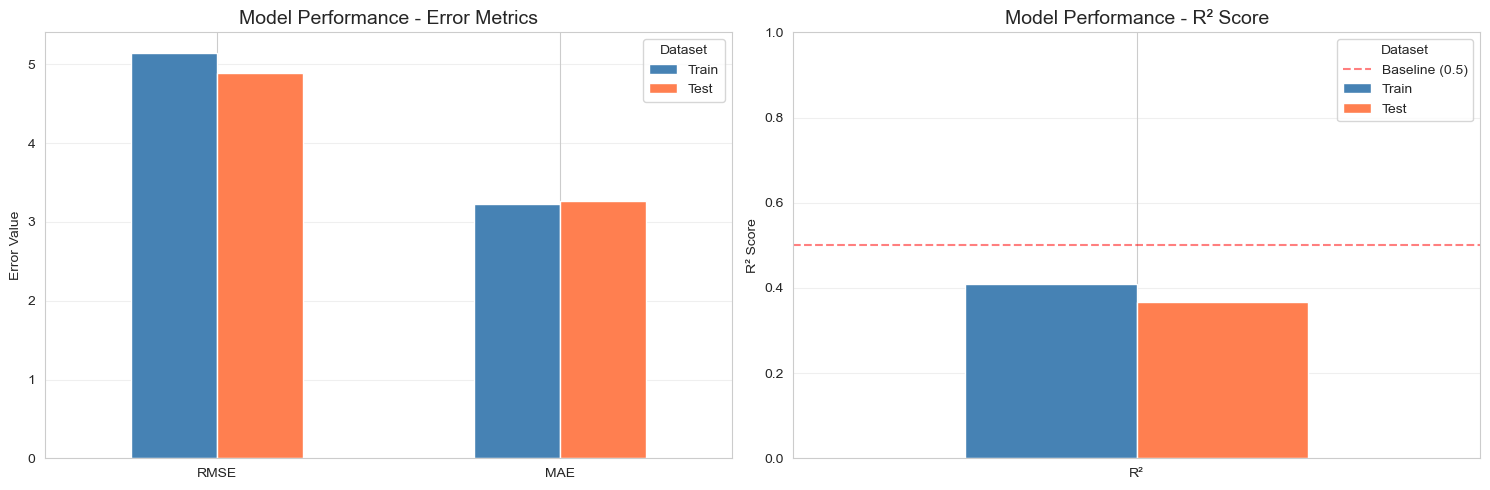

In [10]:
# 성능 비교 시각화
metrics_df = pd.DataFrame({
    'Train': [train_metrics['RMSE'], train_metrics['MAE'], train_metrics['R2']],
    'Test': [test_metrics['RMSE'], test_metrics['MAE'], test_metrics['R2']]
}, index=['RMSE', 'MAE', 'R²'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 절대 지표 (RMSE, MAE)
metrics_df.loc[['RMSE', 'MAE']].plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Model Performance - Error Metrics', fontsize=14)
axes[0].set_ylabel('Error Value')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Dataset')
axes[0].grid(True, alpha=0.3, axis='y')

# R² Score
metrics_df.loc[['R²']].plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('Model Performance - R² Score', fontsize=14)
axes[1].set_ylabel('R² Score')
axes[1].set_ylim([0, 1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline (0.5)')
axes[1].legend(title='Dataset')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 11. Feature Importance (회귀 계수)

=== Linear Regression Coefficients ===
           Feature  Coefficient  Abs_Coefficient
0  avg_temperature    -0.532734         0.532734
6        Sheep_log    -0.219406         0.219406
4        Goats_log    -0.219078         0.219078
1        Cattl_log     0.185142         0.185142
7        Swine_log     0.088327         0.088327
3        Ducks_log     0.059479         0.059479
5        Horse_log    -0.048299         0.048299
2        Chick_log    -0.013534         0.013534
8     rate_landuse    -0.001404         0.001404


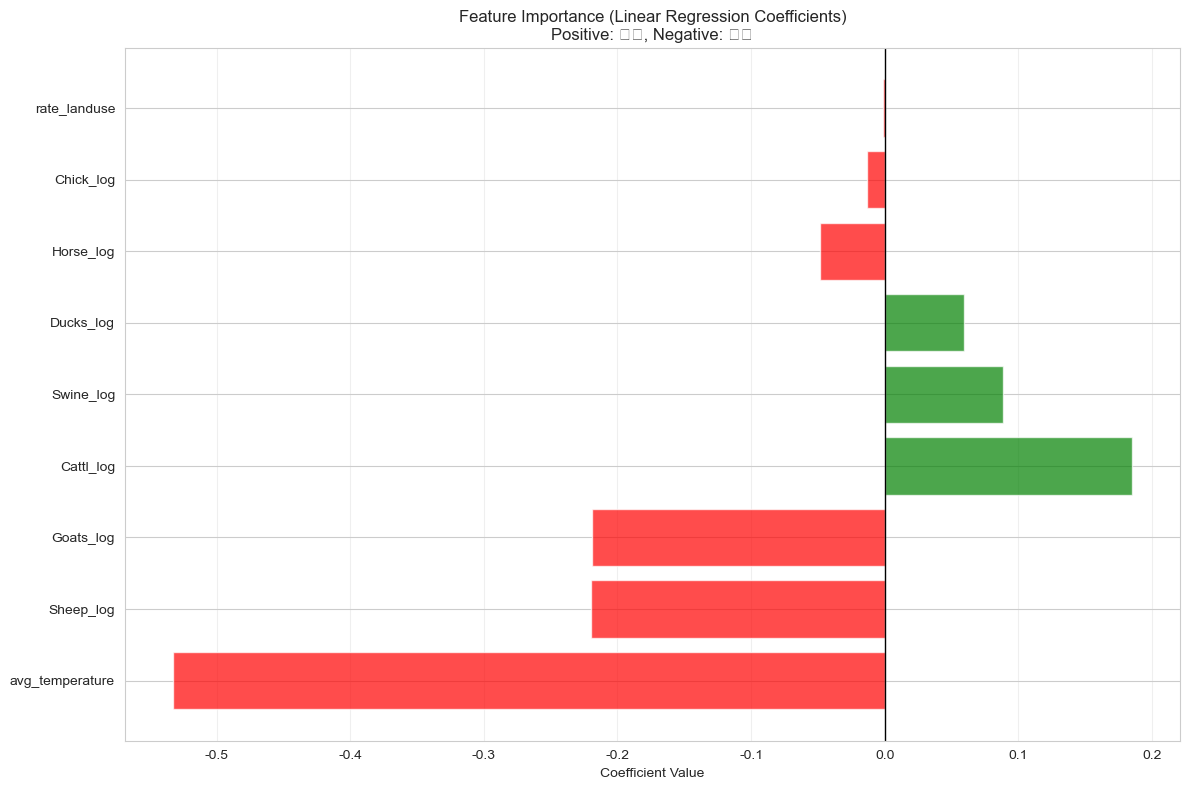

In [11]:
# 회귀 계수 분석
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_,
    'Abs_Coefficient': np.abs(lr_model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("=== Linear Regression Coefficients ===")
print(coefficients)

# 시각화
plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors, alpha=0.7)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Linear Regression Coefficients)\nPositive: 증가, Negative: 감소')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 13. 결과 요약 및 비교

In [12]:
print("="*80)
print("Linear Regression 모델 결과 요약 (개선 버전)")
print("="*80)

print(f"\n1. 모델 성능 (원본 스케일):")
print(f"   Train - R²: {train_metrics['R2']:.4f}, RMSE: {train_metrics['RMSE']:.4f}")
print(f"   Test  - R²: {test_metrics['R2']:.4f}, RMSE: {test_metrics['RMSE']:.4f}")

print(f"\n2. Top 5 중요 Features (절댓값 기준):")
for i, row in coefficients.head(5).iterrows():
    direction = "↑" if row['Coefficient'] > 0 else "↓"
    print(f"   {direction} {row['Feature']}: {row['Coefficient']:.4f}")

print(f"\n3. Overfitting 확인:")
r2_diff = train_metrics['R2'] - test_metrics['R2']
if r2_diff < 0.05:
    print(f"   ✓ 양호 (Train-Test R² 차이: {r2_diff:.4f})")
elif r2_diff < 0.15:
    print(f"   ⚠ 주의 (Train-Test R² 차이: {r2_diff:.4f})")
else:
    print(f"   ✗ Overfitting 가능성 (Train-Test R² 차이: {r2_diff:.4f})")


Linear Regression 모델 결과 요약 (개선 버전)

1. 모델 성능 (원본 스케일):
   Train - R²: 0.4085, RMSE: 5.1506
   Test  - R²: 0.3670, RMSE: 4.8878

2. Top 5 중요 Features (절댓값 기준):
   ↓ avg_temperature: -0.5327
   ↓ Sheep_log: -0.2194
   ↓ Goats_log: -0.2191
   ↑ Cattl_log: 0.1851
   ↑ Swine_log: 0.0883

3. Overfitting 확인:
   ✓ 양호 (Train-Test R² 차이: 0.0415)
